# Fairness x KV-affinity grid comparison (exps 69-102)

A **2 x 2 x 5 grid** run with identical load / dataset / users (64 users x 10 convs, CodeFlowBench):

- **router_mode**: `pull` vs `central-push`
- **fairness**: `vanilla` (fair pull OFF) vs `fair` (fair pull ON, margin 1.15)
- **strategy**: `none`, `prefix`, `affinity-hard`, `affinity-soft`, `both`

| block | exps | strategies |
|---|---|---|
| pull / vanilla | 69,70,71,72,73 | none, prefix, aff-hard, aff-soft, both |
| pull / fair | 74,75,76,77,78 | none, prefix, aff-hard, aff-soft, both |
| central-push / vanilla | 79,80,97,98,99 | none, prefix, aff-hard, aff-soft, both |
| central-push / fair | 100,101,102,... | none, prefix, aff-hard, (aff-soft + both pending) |

**Two analysis axes:**
1. **Fairness / load-balance quality** - how evenly requests, tokens and in-flight work spread across pods, and how much fair pull improves it (vanilla -> fair delta).
2. **KV-affinity quality** - KV-hit fraction, stickiness and prefix reuse, and whether enabling fairness degrades affinity (the tradeoff).

Cells with no `run_summary.json` yet (e.g. a running cell) are auto-skipped and picked up on re-run. Set `EXPERIMENTS_ROOT` and Run All.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

try:
    import yaml
except Exception:
    yaml = None

# ---- config ----------------------------------------------------------------
EXPERIMENTS_ROOT = "/home/saeid/llm-la/src/client/experiments"

# 2 x 2 x 5 grid: router_mode {pull, central-push} x fairness {vanilla, fair}
# x strategy {none, prefix, affinity-hard, affinity-soft, both}.
GRID_IDS = [
    69, 70, 71, 72, 73,      # pull / vanilla
    74, 75, 76, 77, 78,      # pull / fair
    79, 80, 97, 98, 99,      # central-push / vanilla
    100, 101, 102,           # central-push / fair (102 running; aff-soft + both pending)
]
# The pending central-push-fair cells (aff-soft, both) get NEW experiment ids
# when they finish -- add them here and re-run. Any listed cell without a
# run_summary.json is auto-skipped, so 102 is picked up automatically too.
EXTRA_IDS = []

RESULT_TIMEOUT_S = 10000.0   # router hard end-to-end ceiling (for timeout counting)

MODE_SHORT = {"pull": "pull", "central-push": "cpush"}
STRAT_ORDER = ["none", "prefix", "aff-hard", "aff-soft", "both-hard", "both-soft"]
FAIR_COLORS = {False: "#4C78A8", True: "#E45756"}  # vanilla / fair

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 80)

def _read_json(p):
    p = Path(p)
    return json.load(p.open()) if p.is_file() else None

def _read_ndjson(p):
    p = Path(p); rows = []
    if not p.is_file():
        return rows
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception:
                pass
    return rows

def exp_dir(exp_id):
    return Path(EXPERIMENTS_ROOT) / str(exp_id)

def strat_label(strategy, aff_mode):
    """Compact strategy label: affinity/both carry their hard|soft mode."""
    if strategy in ("affinity", "both"):
        base = "aff" if strategy == "affinity" else "both"
        return f"{base}-{aff_mode or '?'}"
    return strategy or "?"


## 1. Experiment registry

In [2]:
def load_meta(exp_id):
    m = {"exp": exp_id, "router_mode": None, "fair": None, "strategy": None,
         "aff_mode": None, "hold_s": None, "fair_margin": None, "batch": None,
         "total_convs": None, "wall_s": None, "load_s": None, "done": False}
    # authoritative deployed settings
    hv = exp_dir(exp_id) / "helm-effective-values.yaml"
    if hv.is_file() and yaml is not None:
        try:
            h = (yaml.safe_load(hv.open()) or {}).get("router", {}) or {}
            m["router_mode"] = h.get("mode")
            m["fair"] = bool(h.get("fairPull"))
            m["strategy"] = h.get("strategy")
            m["aff_mode"] = h.get("affinityMode")
            m["hold_s"] = h.get("affinityHardTimeoutS")
            m["fair_margin"] = h.get("fairMargin")
        except Exception as e:
            print(f"[warn] exp {exp_id} helm parse: {e}")
    # batch size lives in the client config's model spec
    cu = exp_dir(exp_id) / "config_used.yaml"
    if cu.is_file() and yaml is not None:
        try:
            models = ((yaml.safe_load(cu.open()) or {}).get("helm", {}) or {}).get("models") or []
            if models:
                m["batch"] = (models[0] or {}).get("batchSize")
        except Exception:
            pass
    rs = _read_json(exp_dir(exp_id) / "run_summary.json")
    if rs:
        m["done"] = True
        m["wall_s"] = rs.get("wall_time_s")
        m["load_s"] = rs.get("load_runner_duration_s")
        m["total_convs"] = rs.get("total_requests")
    m["strat_lab"] = strat_label(m["strategy"], m["aff_mode"])
    return m

_ALL_IDS = [e for e in (GRID_IDS + EXTRA_IDS) if exp_dir(e).is_dir()]
_META = {e: load_meta(e) for e in _ALL_IDS}

# keep only completed runs, preserving grid order
EXP_IDS = [e for e in (GRID_IDS + EXTRA_IDS) if _META.get(e, {}).get("done")]
_SKIPPED = [e for e in _ALL_IDS if not _META[e]["done"]]
if _SKIPPED:
    print("[skip] no run_summary.json yet (running/incomplete):", _SKIPPED)
_MISSING = [e for e in (GRID_IDS + EXTRA_IDS) if not exp_dir(e).is_dir()]
if _MISSING:
    print("[skip] experiment dir not found (not run yet):", _MISSING)

def _label(exp):
    m = _META[exp]
    ms = MODE_SHORT.get(m["router_mode"], m["router_mode"] or "?")
    fp = "fair" if m["fair"] else "van"
    return f"{exp}:{ms}/{m['strat_lab']}/{fp}"

LABELS = {e: _label(e) for e in EXP_IDS}
REG = pd.DataFrame([_META[e] for e in EXP_IDS]).set_index("exp")
REG["label"] = [LABELS[e] for e in REG.index]
REG["strat_lab"] = pd.Categorical(REG["strat_lab"], categories=STRAT_ORDER, ordered=True)

# ---- shared faceting / pairing helpers -------------------------------------
_DIMS = ["router_mode", "fair", "strat_lab"]

def by_label_frame(obj):
    """Reindex a per-label Series/DataFrame to EXP_IDS order and attach grid dims."""
    d = obj.to_frame() if isinstance(obj, pd.Series) else obj.copy()
    d = d.reindex([LABELS[e] for e in EXP_IDS])
    dims = REG.set_index("label")[_DIMS]
    return d.join(dims)

def grid_bar(obj, title, ylabel, ylim=None, fmt="{:.2f}"):
    """Bar chart across the grid: x ordered by (mode, strategy), colored vanilla/fair."""
    d = by_label_frame(obj)
    col = d.columns[0]
    d = d.sort_values(["router_mode", "strat_lab", "fair"])
    colors = d["fair"].map(FAIR_COLORS)
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(range(len(d)), d[col].values, color=colors.values, edgecolor="black")
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels(d.index, rotation=40, ha="right", fontsize=7)
    ax.set_title(title); ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend(handles=[Patch(color=FAIR_COLORS[False], label="vanilla"),
                       Patch(color=FAIR_COLORS[True], label="fair")], fontsize=8)
    for i, v in enumerate(d[col].values):
        if pd.notna(v):
            ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=6)
    plt.tight_layout(); plt.show()
    return d

def pair_delta(obj, valcol=None):
    """vanilla vs fair table keyed by (router_mode, strat_lab) with delta = fair - vanilla."""
    d = by_label_frame(obj)
    col = valcol or [c for c in d.columns if c not in _DIMS][0]
    piv = d.pivot_table(index=["router_mode", "strat_lab"], columns="fair",
                        values=col, observed=True)
    piv = piv.rename(columns={False: "vanilla", True: "fair"})
    if "vanilla" in piv.columns and "fair" in piv.columns:
        piv["delta"] = piv["fair"] - piv["vanilla"]
    return piv

REG[["router_mode", "fair", "strategy", "aff_mode", "strat_lab", "hold_s",
     "fair_margin", "batch", "total_convs", "wall_s", "label"]]

,router_mode,fair,strategy,aff_mode,strat_lab,hold_s,fair_margin,batch,total_convs,wall_s,label
exp,,,,,,,,,,,
69,pull,False,none,hard,none,600.0,1.25,32,640,11992.790,69:pull/none/van
70,pull,False,prefix,hard,prefix,600.0,1.25,32,640,10775.987,70:pull/prefix/van
71,pull,False,affinity,hard,aff-hard,600.0,1.25,32,640,11802.182,71:pull/aff-hard/van
72,pull,False,affinity,soft,aff-soft,600.0,1.25,32,640,11553.680,72:pull/aff-soft/van
73,pull,False,both,hard,both-hard,600.0,1.25,32,640,12786.830,73:pull/both-hard/van
74,pull,True,none,hard,none,600.0,1.15,32,640,7655.471,74:pull/none/fair
75,pull,True,prefix,hard,prefix,600.0,1.15,32,640,10451.640,75:pull/prefix/fair
76,pull,True,affinity,hard,aff-hard,600.0,1.15,32,640,11472.753,76:pull/aff-hard/fair
77,pull,True,affinity,soft,aff-soft,600.0,1.15,32,640,10711.487,77:pull/aff-soft/fair


## 2. Logs analysis (per-request truth)

Every `logs.json` tagged by `exp`; conversation `group` + per-conversation turn occurrence (`occ`) so we can split single-turn vs multi-turn repeat turns.

In [3]:
KEEP = ["idx", "req_id", "conversation_id", "turn_idx", "num_turns",
        "affinity_key", "endpoint_id", "kv_hit", "kv_hits_len", "total_blocks",
        "matched_tokens", "ttft_s", "end_to_end_s", "model_latency_s",
        "prompt_tokens", "completion_tokens", "cache_read_input_tokens",
        "finish_reason", "send_failed", "t0_wall", "t1_wall"]

def load_logs(exp_id):
    rows = _read_ndjson(exp_dir(exp_id) / "logs.json")
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    for c in KEEP:
        if c not in df.columns:
            df[c] = np.nan
    df = df[KEEP].copy()
    df["exp"] = exp_id
    df["label"] = LABELS[exp_id]
    grp = df["conversation_id"].astype("object")
    grp = grp.where(grp.notna(), df["affinity_key"])
    grp = grp.where(grp.notna(), "req:" + df["req_id"].astype(str))
    df["group"] = grp.astype(str)
    for c in ["kv_hits_len", "total_blocks", "matched_tokens", "ttft_s",
              "end_to_end_s", "prompt_tokens", "completion_tokens",
              "cache_read_input_tokens", "t0_wall", "t1_wall"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["kv_hit"] = df["kv_hit"].map(lambda x: bool(x) if pd.notna(x) else np.nan)
    df["failed"] = df["send_failed"].fillna(False).astype(bool)
    return df

LOGS = pd.concat([load_logs(e) for e in EXP_IDS], ignore_index=True)
LOGS = LOGS.merge(REG[["router_mode", "fair", "strat_lab"]],
                  left_on="exp", right_index=True, how="left")
LOGS = LOGS.sort_values(["exp", "group", "t0_wall"]).reset_index(drop=True)
LOGS["occ"] = LOGS.groupby(["exp", "group"]).cumcount()
LOGS["gsize"] = LOGS.groupby(["exp", "group"])["req_id"].transform("size")
def _turn_type(row):
    if row["gsize"] == 1:
        return "single"
    return "first" if row["occ"] == 0 else "repeat"
LOGS["turn_type"] = LOGS.apply(_turn_type, axis=1)
print("rows:", len(LOGS), "| per exp:")
print(LOGS.groupby("label").size())

rows: 25565 | per exp:
label
100:cpush/none/fair        1414
101:cpush/prefix/fair      1410
102:cpush/aff-hard/fair    1420
69:pull/none/van           1427
70:pull/prefix/van         1415
71:pull/aff-hard/van       1427
72:pull/aff-soft/van       1427
73:pull/both-hard/van      1426
74:pull/none/fair          1426
75:pull/prefix/fair        1427
76:pull/aff-hard/fair      1422
77:pull/aff-soft/fair      1413
78:pull/both-hard/fair     1426
79:cpush/none/van          1418
80:cpush/prefix/van        1414
97:cpush/aff-hard/van      1429
98:cpush/aff-soft/van      1418
99:cpush/both-hard/van     1406
dtype: int64


### 2a. KV-hit fraction (overall + by turn type)

,kv_hit_frac,first,repeat,single
label,,,,
69:pull/none/van,0.7435,0.8640,0.7176,0.6990
70:pull/prefix/van,0.9979,0.9937,1.0000,0.9985
71:pull/aff-hard/van,0.9986,0.9974,1.0000,0.9979
72:pull/aff-soft/van,0.9979,0.9948,1.0000,0.9979
73:pull/both-hard/van,0.9986,0.9974,1.0000,0.9979
74:pull/none/fair,0.9201,0.8982,0.9334,0.9204
75:pull/prefix/fair,0.9580,0.9688,0.9710,0.9439
76:pull/aff-hard/fair,0.9944,0.9893,1.0000,0.9921
77:pull/aff-soft/fair,0.9943,0.9898,1.0000,0.9915


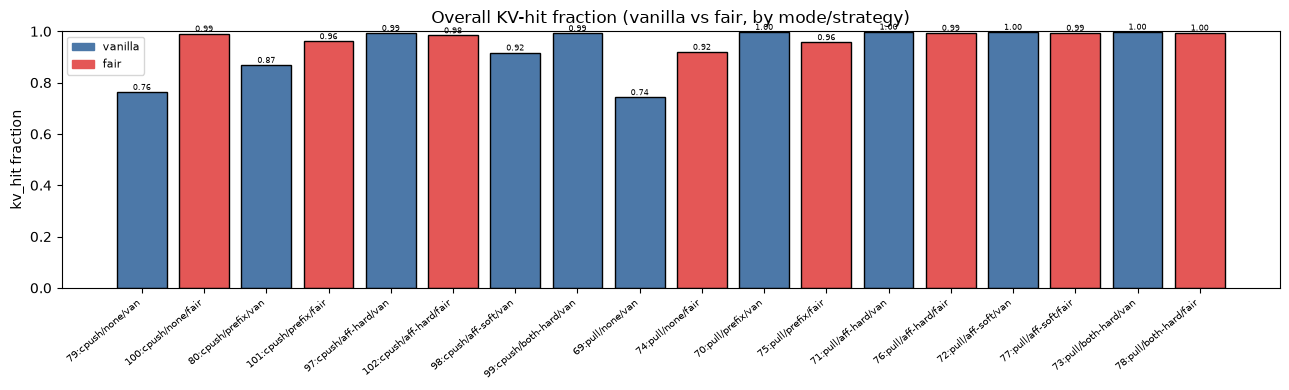

,kv_hit_frac,router_mode,fair,strat_lab
label,,,,
79:cpush/none/van,0.763752,central-push,False,none
100:cpush/none/fair,0.991513,central-push,True,none
80:cpush/prefix/van,0.869165,central-push,False,prefix
101:cpush/prefix/fair,0.961702,central-push,True,prefix
97:cpush/aff-hard/van,0.993702,central-push,False,aff-hard
102:cpush/aff-hard/fair,0.984507,central-push,True,aff-hard
98:cpush/aff-soft/van,0.917489,central-push,False,aff-soft
99:cpush/both-hard/van,0.992888,central-push,False,both-hard
69:pull/none/van,0.743518,pull,False,none


In [4]:
ok = LOGS[~LOGS["failed"] & LOGS["kv_hit"].notna()].copy()
ok["kv_hit_b"] = ok["kv_hit"].astype(bool)

kv_overall = ok.groupby("label")["kv_hit_b"].mean().rename("kv_hit_frac")
kv_by_type = ok.pivot_table(index="label", columns="turn_type",
                            values="kv_hit_b", aggfunc="mean")
kv_tbl = pd.concat([kv_overall, kv_by_type], axis=1)
kv_tbl = kv_tbl.reindex([LABELS[e] for e in EXP_IDS])
display(kv_tbl.round(4))

grid_bar(kv_overall, "Overall KV-hit fraction (vanilla vs fair, by mode/strategy)",
         "kv_hit fraction", ylim=(0, 1))

### 2b. Affinity stickiness (distinct pods per conversation)

,conversations,multi_turn,sticky_frac,avg_distinct_ep,max_distinct_ep
label,,,,,
69:pull/none/van,949.0,331.0,0.4230,1.5770,2.0
70:pull/prefix/van,965.0,319.0,0.4828,1.5172,2.0
71:pull/aff-hard/van,873.0,390.0,1.0000,1.0000,1.0
72:pull/aff-soft/van,866.0,386.0,0.4275,1.5725,2.0
73:pull/both-hard/van,868.0,386.0,1.0000,1.0000,1.0
74:pull/none/fair,810.0,383.0,0.3525,1.6475,2.0
75:pull/prefix/fair,979.0,320.0,0.4281,1.5719,2.0
76:pull/aff-hard/fair,878.0,373.0,1.0000,1.0000,1.0
77:pull/aff-soft/fair,864.0,392.0,0.3929,1.6071,2.0


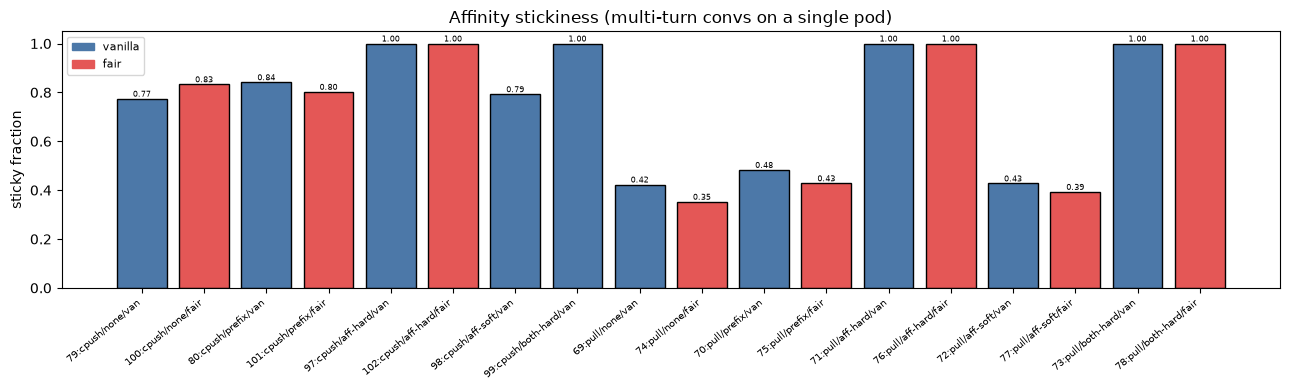

,sticky_frac,router_mode,fair,strat_lab
label,,,,
79:cpush/none/van,0.7742,central-push,False,none
100:cpush/none/fair,0.8333,central-push,True,none
80:cpush/prefix/van,0.8416,central-push,False,prefix
101:cpush/prefix/fair,0.8024,central-push,True,prefix
97:cpush/aff-hard/van,1.0000,central-push,False,aff-hard
102:cpush/aff-hard/fair,1.0000,central-push,True,aff-hard
98:cpush/aff-soft/van,0.7927,central-push,False,aff-soft
99:cpush/both-hard/van,1.0000,central-push,False,both-hard
69:pull/none/van,0.4230,pull,False,none


In [5]:
def stickiness(sub):
    v = sub[sub["endpoint_id"].notna()]
    per_conv = v.groupby("group")["endpoint_id"].nunique()
    req_per_conv = v.groupby("group")["req_id"].size()
    multi = per_conv[req_per_conv > 1]
    n_multi = len(multi)
    sticky = int((multi == 1).sum()) if n_multi else 0
    return pd.Series({
        "conversations": int(per_conv.size),
        "multi_turn": int(n_multi),
        "sticky_frac": round(sticky / n_multi, 4) if n_multi else np.nan,
        "avg_distinct_ep": round(float(multi.mean()), 4) if n_multi else np.nan,
        "max_distinct_ep": int(multi.max()) if n_multi else np.nan,
    })

STICK = LOGS[~LOGS["failed"]].groupby("label").apply(stickiness)
STICK = STICK.reindex([LABELS[e] for e in EXP_IDS])
display(STICK)

grid_bar(STICK["sticky_frac"], "Affinity stickiness (multi-turn convs on a single pod)",
         "sticky fraction", ylim=(0, 1.05))

### 2c. Per-pod load balance + per-pod KV-hit

In [6]:
def per_pod(sub):
    v = sub[sub["endpoint_id"].notna() & ~sub["failed"]]
    g = v.groupby("endpoint_id").agg(
        requests=("req_id", "size"),
        conversations=("group", "nunique"),
        kv_hit_frac=("kv_hit", lambda s: pd.Series(s).dropna().astype(bool).mean()),
        matched_tokens=("matched_tokens", "sum"),
    )
    return g

for e in EXP_IDS:
    sub = LOGS[LOGS["exp"] == e]
    pp = per_pod(sub)
    if pp.empty:
        continue
    r = pp["requests"]
    imb = r.max() / r.mean() if len(r) > 1 else 1.0
    print(f"=== {LABELS[e]} | load imbalance max/mean = {imb:.2f}x ===")
    display(pp.round(4))

=== 69:pull/none/van | load imbalance max/mean = 1.01x ===


,requests,conversations,kv_hit_frac,matched_tokens
endpoint_id,,,,
vllm-minimax-m2-0,720,574,0.7556,278656
vllm-minimax-m2-1,707,566,0.7313,206720


=== 70:pull/prefix/van | load imbalance max/mean = 1.08x ===


,requests,conversations,kv_hit_frac,matched_tokens
endpoint_id,,,,
vllm-minimax-m2-0,763,603,0.9974,321024
vllm-minimax-m2-1,652,527,0.9985,254976


=== 71:pull/aff-hard/van | load imbalance max/mean = 1.05x ===


...

,requests,conversations,kv_hit_frac,matched_tokens
endpoint_id,,,,
vllm-minimax-m2-0,966,667,0.9938,361344
vllm-minimax-m2-1,448,327,0.9866,226688


=== 101:cpush/prefix/fair | load imbalance max/mean = 1.35x ===


,requests,conversations,kv_hit_frac,matched_tokens
endpoint_id,,,,
vllm-minimax-m2-0,951,653,0.9516,348288
vllm-minimax-m2-1,459,348,0.9826,464768


=== 102:cpush/aff-hard/fair | load imbalance max/mean = 1.41x ===


,requests,conversations,kv_hit_frac,matched_tokens
endpoint_id,,,,
vllm-minimax-m2-0,1000,620,0.9930,866432
vllm-minimax-m2-1,420,253,0.9643,394752


### 2d. Fairness / load-balance quality

How evenly is work spread across pods, and does fair pull improve it? Two views:

1. **Request-level (from `logs.json`)** - per-pod request / token / conversation share, summarized as Jain's fairness index (1.0 = perfectly even), coefficient of variation (CoV, lower = even) and max/mean imbalance.
2. **In-flight (from `metrics.jsonl`)** - cross-pod coefficient of variation of `requests_running + requests_waiting` over time; this is what fair pull directly acts on (it trims work from pods running hotter than `fair_margin` x fleet-average).

Bars are colored vanilla (blue) vs fair (red); the vanilla->fair delta is shown at the end of the section.

,n_pods,req_jain,req_cov,req_maxmean,tok_jain,tok_cov,conv_cov
69:pull/none/van,2.0,0.9999,0.0091,1.0091,0.9979,0.0457,0.0070
70:pull/prefix/van,2.0,0.9939,0.0784,1.0784,0.9989,0.0338,0.0673
71:pull/aff-hard/van,2.0,0.9971,0.0540,1.0540,0.9944,0.0751,0.0538
72:pull/aff-soft/van,2.0,0.9975,0.0498,1.0498,0.9971,0.0536,0.0524
73:pull/both-hard/van,2.0,0.9994,0.0252,1.0252,0.9909,0.0960,0.0276
74:pull/none/fair,2.0,0.9876,0.1122,1.1122,0.9911,0.0949,0.0832
75:pull/prefix/fair,2.0,0.9997,0.0161,1.0161,0.9995,0.0232,0.0069
76:pull/aff-hard/fair,2.0,1.0000,0.0070,1.0070,0.9895,0.1028,0.0023
77:pull/aff-soft/fair,2.0,0.9989,0.0333,1.0333,0.9998,0.0125,0.0200
78:pull/both-hard/fair,2.0,0.9957,0.0659,1.0659,0.9880,0.1104,0.0587


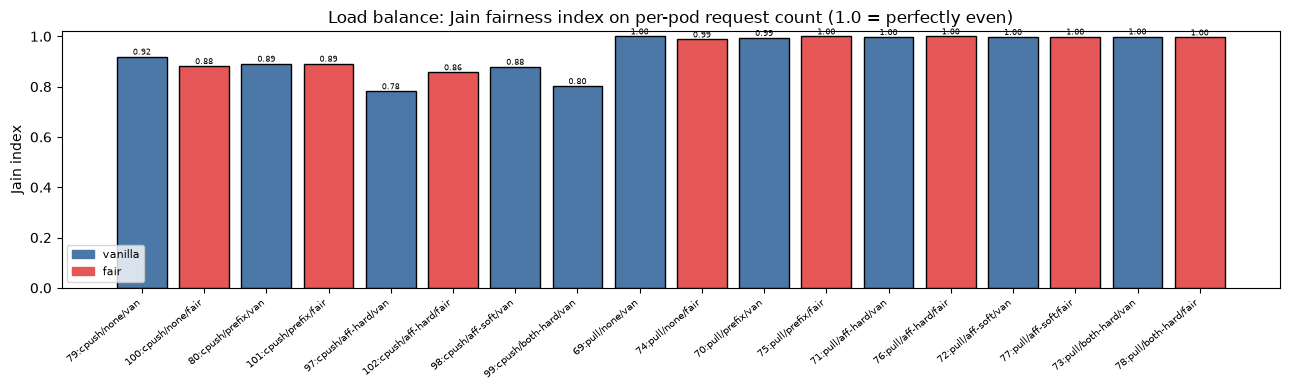

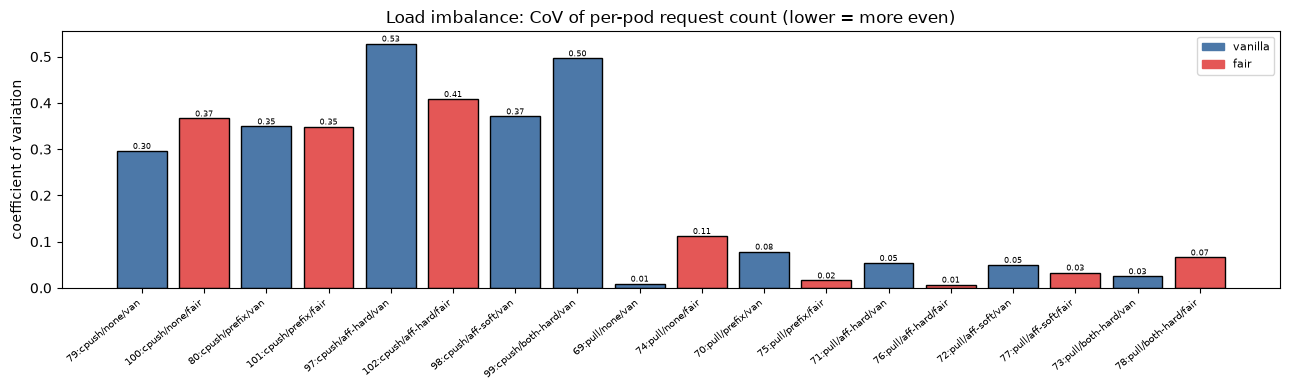

,req_cov,router_mode,fair,strat_lab
79:cpush/none/van,0.296192,central-push,False,none
100:cpush/none/fair,0.366337,central-push,True,none
80:cpush/prefix/van,0.349364,central-push,False,prefix
101:cpush/prefix/fair,0.348936,central-push,True,prefix
97:cpush/aff-hard/van,0.528341,central-push,False,aff-hard
102:cpush/aff-hard/fair,0.408451,central-push,True,aff-hard
98:cpush/aff-soft/van,0.370945,central-push,False,aff-soft
99:cpush/both-hard/van,0.496444,central-push,False,both-hard
69:pull/none/van,0.009110,pull,False,none
74:pull/none/fair,0.112202,pull,True,none


In [7]:
# --- Request-level load balance (from per-request logs) ---
def _jain(x):
    x = np.asarray(x, dtype=float); s = x.sum()
    return float(s * s / (len(x) * np.sum(x * x))) if (len(x) and s > 0) else np.nan

def _cov(x):
    x = np.asarray(x, dtype=float); m = x.mean()
    return float(x.std(ddof=0) / m) if m > 0 else np.nan

def _maxmean(x):
    x = np.asarray(x, dtype=float); m = x.mean()
    return float(x.max() / m) if m > 0 else np.nan

def load_balance_logs(sub):
    v = sub[sub["endpoint_id"].notna() & ~sub["failed"]]
    if v.empty:
        return None
    req = v.groupby("endpoint_id")["req_id"].size()
    tok = (v.assign(_t=v["prompt_tokens"].fillna(0) + v["completion_tokens"].fillna(0))
             .groupby("endpoint_id")["_t"].sum())
    conv = v.groupby("endpoint_id")["group"].nunique()
    return {
        "n_pods": int(req.size),
        "req_jain": _jain(req), "req_cov": _cov(req), "req_maxmean": _maxmean(req),
        "tok_jain": _jain(tok), "tok_cov": _cov(tok),
        "conv_cov": _cov(conv),
    }

FAIR = pd.DataFrame({LABELS[e]: load_balance_logs(LOGS[LOGS["exp"] == e])
                     for e in EXP_IDS}).T
FAIR = FAIR.reindex([LABELS[e] for e in EXP_IDS])
display(FAIR.round(4))

grid_bar(FAIR["req_jain"],
         "Load balance: Jain fairness index on per-pod request count (1.0 = perfectly even)",
         "Jain index", ylim=(0, 1.02))
grid_bar(FAIR["req_cov"],
         "Load imbalance: CoV of per-pod request count (lower = more even)",
         "coefficient of variation")

,n_pods,req_jain,req_cov,tok_cov,inflight_cov_mean,inflight_maxmean_mean
69:pull/none/van,2.0,0.9999,0.0091,0.0457,0.2324,1.2324
70:pull/prefix/van,2.0,0.9939,0.0784,0.0338,0.2762,1.2762
71:pull/aff-hard/van,2.0,0.9971,0.0540,0.0751,0.1836,1.1836
72:pull/aff-soft/van,2.0,0.9975,0.0498,0.0536,0.1919,1.1919
73:pull/both-hard/van,2.0,0.9994,0.0252,0.0960,0.2556,1.2556
74:pull/none/fair,2.0,0.9876,0.1122,0.0949,0.6075,1.6075
75:pull/prefix/fair,2.0,0.9997,0.0161,0.0232,0.1497,1.1497
76:pull/aff-hard/fair,2.0,1.0000,0.0070,0.1028,0.3240,1.3240
77:pull/aff-soft/fair,2.0,0.9989,0.0333,0.0125,0.2141,1.2141
78:pull/both-hard/fair,2.0,0.9957,0.0659,0.1104,0.2117,1.2117


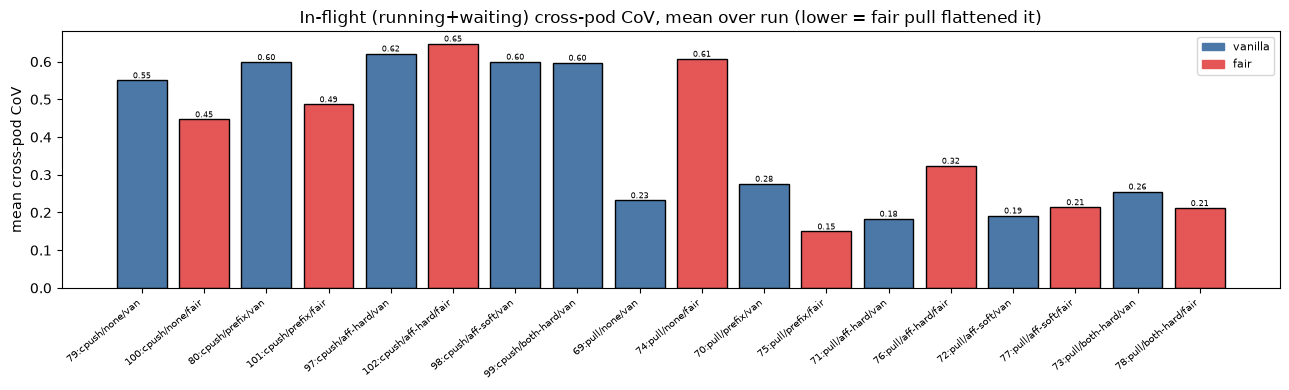

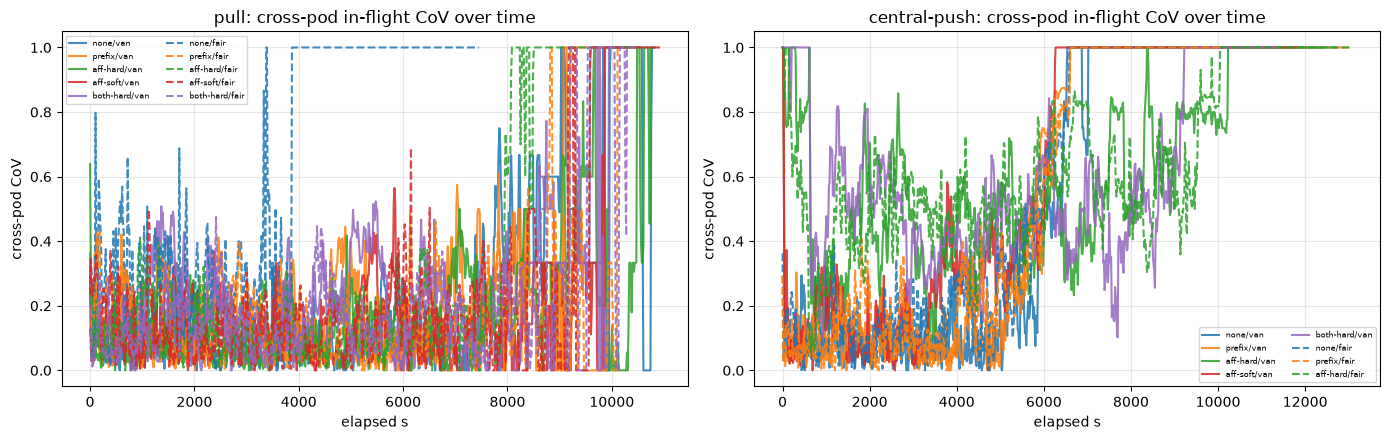

In [8]:
# --- In-flight (running+waiting) balance across pods over time (from metrics.jsonl) ---
def inflight_cov_series(exp_id):
    recs = []
    for r in _read_ndjson(exp_dir(exp_id) / "metrics.jsonl"):
        vals = []
        for s in (r.get("samples") or []):
            rr, rw = s.get("requests_running"), s.get("requests_waiting")
            if rr is None and rw is None:
                continue
            vals.append((rr or 0) + (rw or 0))
        if len(vals) >= 2:
            a = np.asarray(vals, dtype=float); m = a.mean()
            if m > 0:
                recs.append((r.get("ts"), a.std(ddof=0) / m, a.max() / m))
    if not recs:
        return pd.DataFrame(columns=["t_s", "cov", "maxmean"])
    df = pd.DataFrame(recs, columns=["ts", "cov", "maxmean"])
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce", utc=True)
    df = df.dropna(subset=["ts"])
    if df.empty:
        return pd.DataFrame(columns=["t_s", "cov", "maxmean"])
    df["t_s"] = (df["ts"] - df["ts"].min()).dt.total_seconds()
    return df[["t_s", "cov", "maxmean"]]

IBS = {e: inflight_cov_series(e) for e in EXP_IDS}
for e in EXP_IDS:
    d = IBS[e]
    FAIR.loc[LABELS[e], "inflight_cov_mean"] = float(d["cov"].mean()) if not d.empty else np.nan
    FAIR.loc[LABELS[e], "inflight_maxmean_mean"] = float(d["maxmean"].mean()) if not d.empty else np.nan

display(FAIR[["n_pods", "req_jain", "req_cov", "tok_cov",
             "inflight_cov_mean", "inflight_maxmean_mean"]].round(4))

grid_bar(FAIR["inflight_cov_mean"],
         "In-flight (running+waiting) cross-pod CoV, mean over run (lower = fair pull flattened it)",
         "mean cross-pod CoV")

# time series of cross-pod in-flight CoV, one subplot per router_mode, van solid / fair dashed
modes = [m for m in ["pull", "central-push"] if (REG["router_mode"] == m).any()]
if modes:
    fig, axes = plt.subplots(1, len(modes), figsize=(7 * len(modes), 4.5), squeeze=False)
    strat_colors = {s: c for s, c in zip(STRAT_ORDER, plt.cm.tab10.colors)}
    for ax, m in zip(axes.ravel(), modes):
        for e in EXP_IDS:
            if REG.loc[e, "router_mode"] != m:
                continue
            d = IBS[e]
            if d.empty:
                continue
            sl = str(REG.loc[e, "strat_lab"]); fair = bool(REG.loc[e, "fair"])
            db = d.assign(bin=(d["t_s"] // 15 * 15).astype(int)).groupby("bin")["cov"].mean()
            ax.plot(db.index, db.values, color=strat_colors.get(sl, "grey"),
                    ls="--" if fair else "-", alpha=.85,
                    label=f"{sl}/{'fair' if fair else 'van'}")
        ax.set_title(f"{m}: cross-pod in-flight CoV over time")
        ax.set_xlabel("elapsed s"); ax.set_ylabel("cross-pod CoV"); ax.grid(alpha=.3)
        ax.legend(fontsize=6, ncol=2)
    plt.tight_layout(); plt.show()

#### vanilla -> fair load-balance delta

Paired within each `(router_mode, strategy)`: `delta = fair - vanilla`. Fair pull is working where `req_jain` goes **up** (toward 1.0) and `inflight_cov` goes **down**. Expect the biggest improvement on `aff-hard` / `both` (affinity concentrates load) and near-zero on `none` (already balanced).

In [9]:
print("Jain fairness index on per-pod request count (delta = fair - vanilla; higher is better):")
display(pair_delta(FAIR["req_jain"]).round(4))
print("Per-pod request-count CoV (delta = fair - vanilla; negative is better):")
display(pair_delta(FAIR["req_cov"]).round(4))
print("In-flight cross-pod CoV (delta = fair - vanilla; negative is better):")
display(pair_delta(FAIR["inflight_cov_mean"]).round(4))

Jain fairness index on per-pod request count (delta = fair - vanilla; higher is better):


fair                    vanilla    fair   delta
router_mode  strat_lab                         
central-push none        0.9193  0.8817 -0.0377
             prefix      0.8912  0.8915  0.0002
             aff-hard    0.7818  0.8570  0.0752
             aff-soft    0.8790     NaN     NaN
             both-hard   0.8023     NaN     NaN
pull         none        0.9999  0.9876 -0.0123
             prefix      0.9939  0.9997  0.0059
             aff-hard    0.9971  1.0000  0.0029
             aff-soft    0.9975  0.9989  0.0014
             both-hard   0.9994  0.9957 -0.0037

Per-pod request-count CoV (delta = fair - vanilla; negative is better):


fair                    vanilla    fair   delta
router_mode  strat_lab                         
central-push none        0.2962  0.3663  0.0701
             prefix      0.3494  0.3489 -0.0004
             aff-hard    0.5283  0.4085 -0.1199
             aff-soft    0.3709     NaN     NaN
             both-hard   0.4964     NaN     NaN
pull         none        0.0091  0.1122  0.1031
             prefix      0.0784  0.0161 -0.0623
             aff-hard    0.0540  0.0070 -0.0469
             aff-soft    0.0498  0.0333 -0.0165
             both-hard   0.0252  0.0659  0.0407

In-flight cross-pod CoV (delta = fair - vanilla; negative is better):


fair                    vanilla    fair   delta
router_mode  strat_lab                         
central-push none        0.5505  0.4470 -0.1034
             prefix      0.5987  0.4869 -0.1119
             aff-hard    0.6215  0.6479  0.0264
             aff-soft    0.5998     NaN     NaN
             both-hard   0.5971     NaN     NaN
pull         none        0.2324  0.6075  0.3751
             prefix      0.2762  0.1497 -0.1265
             aff-hard    0.1836  0.3240  0.1404
             aff-soft    0.1919  0.2141  0.0222
             both-hard   0.2556  0.2117 -0.0439

### 2e. Latency: TTFT + end-to-end percentiles

,e2e_p50,e2e_p95,e2e_p99,e2e_max,ttft_p50,ttft_p95,ttft_p99,near_timeout,failed
label,,,,,,,,,
69:pull/none/van,98.600,1495.847,2002.498,2099.506,0.926,2.412,3.076,0,0
70:pull/prefix/van,100.325,1459.594,1948.030,2171.204,0.920,1.437,2.925,0,0
71:pull/aff-hard/van,102.301,1620.095,2198.141,2568.616,0.929,1.763,3.018,0,0
72:pull/aff-soft/van,97.171,1499.831,2024.210,2321.615,0.919,1.574,2.855,0,0
73:pull/both-hard/van,101.997,1610.918,1996.230,2455.341,0.940,1.738,3.015,0,0
74:pull/none/fair,26.015,452.648,1389.811,1630.648,0.792,1.297,1.725,0,0
75:pull/prefix/fair,104.853,1384.140,1854.652,2053.237,0.946,2.390,2.849,0,0
76:pull/aff-hard/fair,99.798,1483.393,1965.487,2086.244,0.964,1.571,2.937,0,0
77:pull/aff-soft/fair,103.394,1449.890,2083.061,2508.998,0.952,1.432,2.713,0,0


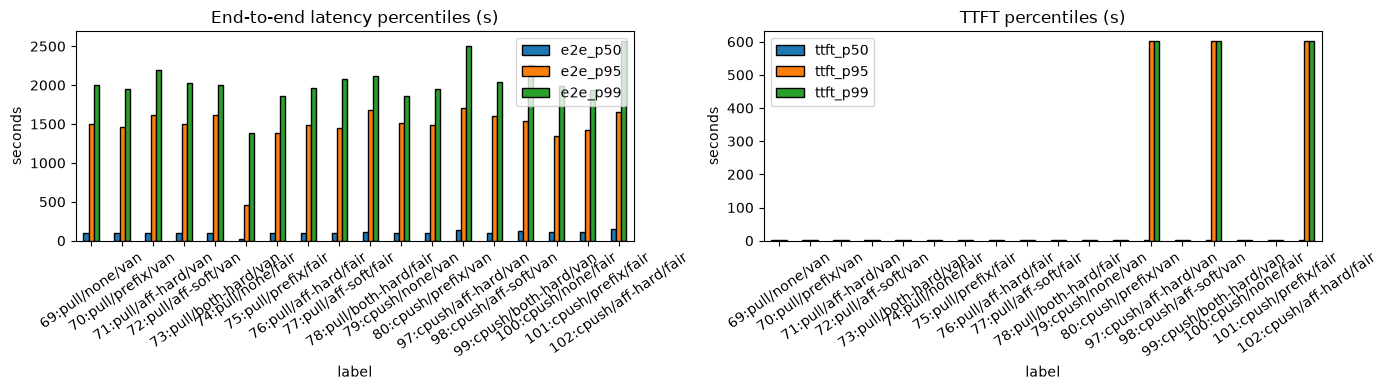

In [10]:
def pcts(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return pd.Series({"p50": np.nan, "p95": np.nan, "p99": np.nan, "max": np.nan})
    return pd.Series({"p50": s.quantile(.50), "p95": s.quantile(.95),
                      "p99": s.quantile(.99), "max": s.max()})

good = LOGS[~LOGS["failed"]]
lat = []
for e in EXP_IDS:
    sub = good[good["exp"] == e]
    e2e = pcts(sub["end_to_end_s"]); ttft = pcts(sub["ttft_s"])
    n_to = int((pd.to_numeric(sub["end_to_end_s"], errors="coerce") >= 0.95 * RESULT_TIMEOUT_S).sum())
    n_fail = int(LOGS[(LOGS["exp"] == e)]["failed"].sum())
    lat.append({"label": LABELS[e],
                "e2e_p50": e2e["p50"], "e2e_p95": e2e["p95"], "e2e_p99": e2e["p99"], "e2e_max": e2e["max"],
                "ttft_p50": ttft["p50"], "ttft_p95": ttft["p95"], "ttft_p99": ttft["p99"],
                "near_timeout": n_to, "failed": n_fail})
LAT = pd.DataFrame(lat).set_index("label").reindex([LABELS[e] for e in EXP_IDS])
display(LAT.round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
LAT[["e2e_p50", "e2e_p95", "e2e_p99"]].plot(kind="bar", ax=ax[0], edgecolor="black")
ax[0].set_title("End-to-end latency percentiles (s)"); ax[0].set_ylabel("seconds")
ax[0].tick_params(axis="x", rotation=35)
LAT[["ttft_p50", "ttft_p95", "ttft_p99"]].plot(kind="bar", ax=ax[1], edgecolor="black")
ax[1].set_title("TTFT percentiles (s)"); ax[1].set_ylabel("seconds")
ax[1].tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()

### 2f. TTFT by turn index (does reuse pay off?)

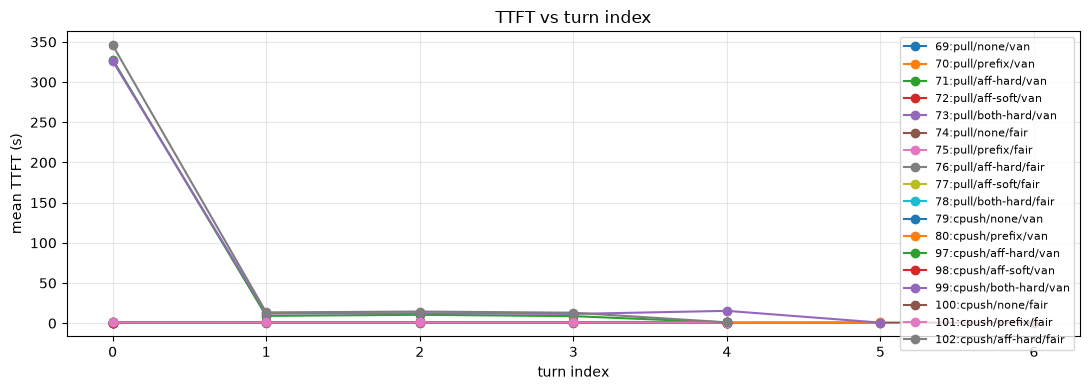

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
for e in EXP_IDS:
    sub = good[(good["exp"] == e) & good["ttft_s"].notna()]
    if sub.empty:
        continue
    by_turn = sub.groupby("turn_idx")["ttft_s"].mean()
    ax.plot(by_turn.index, by_turn.values, marker="o", label=LABELS[e])
ax.set_xlabel("turn index"); ax.set_ylabel("mean TTFT (s)")
ax.set_title("TTFT vs turn index"); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 2g. Prefix-reuse payoff: matched_tokens / kv_hits_len / claude cache_read

,matched_tokens_mean,kv_hits_len_mean,cache_read_mean,cache_read_sum
label,,,,
69:pull/none/van,340.14,2.66,0.0,0.0
70:pull/prefix/van,407.07,3.18,0.0,0.0
71:pull/aff-hard/van,527.79,4.12,0.0,0.0
72:pull/aff-soft/van,365.25,2.85,0.0,0.0
73:pull/both-hard/van,531.39,4.15,0.0,0.0
74:pull/none/fair,323.77,2.53,0.0,0.0
75:pull/prefix/fair,387.41,3.03,0.0,0.0
76:pull/aff-hard/fair,547.65,4.28,0.0,0.0
77:pull/aff-soft/fair,415.62,3.25,0.0,0.0


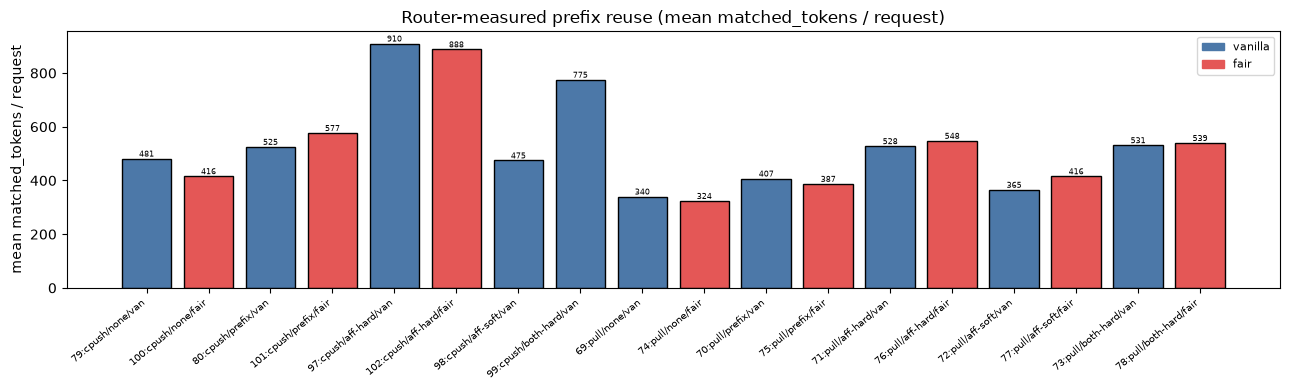

,matched_tokens_mean,router_mode,fair,strat_lab
label,,,,
79:cpush/none/van,481.399154,central-push,False,none
100:cpush/none/fair,415.864215,central-push,True,none
80:cpush/prefix/van,525.125884,central-push,False,prefix
101:cpush/prefix/fair,576.635461,central-push,True,prefix
97:cpush/aff-hard/van,909.794262,central-push,False,aff-hard
102:cpush/aff-hard/fair,888.157746,central-push,True,aff-hard
98:cpush/aff-soft/van,474.629055,central-push,False,aff-soft
99:cpush/both-hard/van,775.100996,central-push,False,both-hard
69:pull/none/van,340.137351,pull,False,none


In [12]:
reuse = good.groupby("label").agg(
    matched_tokens_mean=("matched_tokens", "mean"),
    kv_hits_len_mean=("kv_hits_len", "mean"),
    cache_read_mean=("cache_read_input_tokens", "mean"),
    cache_read_sum=("cache_read_input_tokens", "sum"),
).reindex([LABELS[e] for e in EXP_IDS])
display(reuse.round(2))

grid_bar(reuse["matched_tokens_mean"],
         "Router-measured prefix reuse (mean matched_tokens / request)",
         "mean matched_tokens / request", fmt="{:.0f}")

### 2h. Fairness vs KV-affinity tradeoff

Does turning fair pull ON cost affinity quality? For each `(router_mode, strategy)` pair we compare the fair cell against its vanilla twin: `delta = fair - vanilla`. The load-balance gain (`delta req_jain` up) should ideally come with little or no affinity loss (`delta kv_hit_frac` / `delta sticky_frac` ~ 0). Points in the top-right of the scatter are win-win.

Fairness effect on affinity (delta = fair - vanilla, per mode/strategy)

KV-hit fraction:


fair                    vanilla    fair   delta
router_mode  strat_lab                         
central-push none        0.7638  0.9915  0.2278
             prefix      0.8692  0.9617  0.0925
             aff-hard    0.9937  0.9845 -0.0092
             aff-soft    0.9175     NaN     NaN
             both-hard   0.9929     NaN     NaN
pull         none        0.7435  0.9201  0.1765
             prefix      0.9979  0.9580 -0.0399
             aff-hard    0.9986  0.9944 -0.0042
             aff-soft    0.9979  0.9943 -0.0036
             both-hard   0.9986  0.9951 -0.0035

Stickiness (sticky_frac):


fair                    vanilla    fair   delta
router_mode  strat_lab                         
central-push none        0.7742  0.8333  0.0591
             prefix      0.8416  0.8024 -0.0392
             aff-hard    1.0000  1.0000  0.0000
             aff-soft    0.7927     NaN     NaN
             both-hard   1.0000     NaN     NaN
pull         none        0.4230  0.3525 -0.0705
             prefix      0.4828  0.4281 -0.0547
             aff-hard    1.0000  1.0000  0.0000
             aff-soft    0.4275  0.3929 -0.0346
             both-hard   1.0000  1.0000  0.0000

d_req_jain  d_kv_hit  d_sticky
router_mode  strat_lab                                
central-push none          -0.0377    0.2278    0.0591
             prefix         0.0002    0.0925   -0.0392
             aff-hard       0.0752   -0.0092    0.0000
             aff-soft          NaN       NaN       NaN
             both-hard         NaN       NaN       NaN
pull         none          -0.0123    0.1765   -0.0705
             prefix         0.0059   -0.0399   -0.0547
             aff-hard       0.0029   -0.0042    0.0000
             aff-soft       0.0014   -0.0036   -0.0346
             both-hard     -0.0037   -0.0035    0.0000

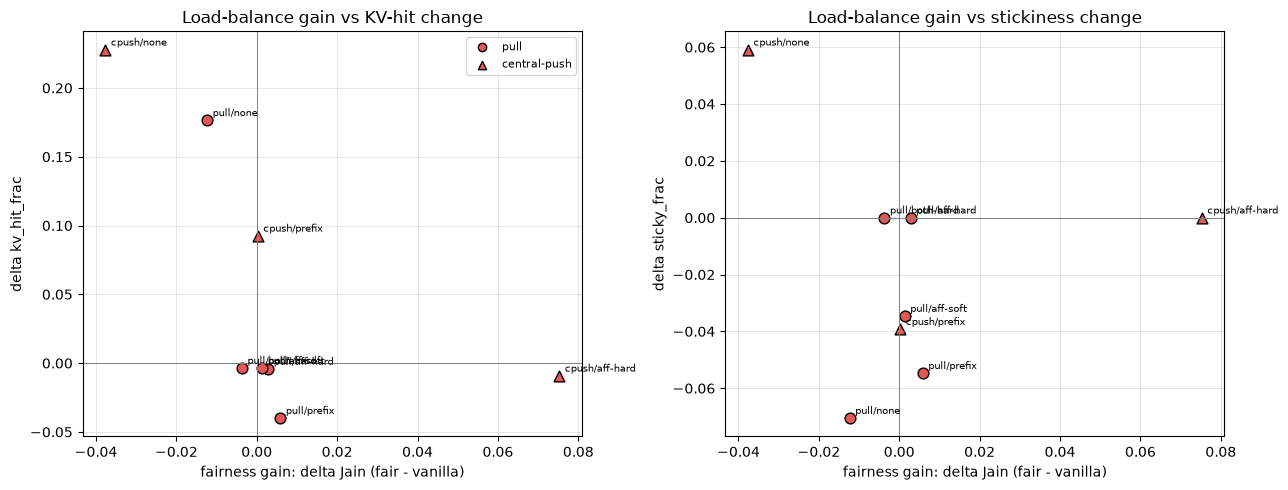

In [13]:
print("Fairness effect on affinity (delta = fair - vanilla, per mode/strategy)")
print("\nKV-hit fraction:")
display(pair_delta(kv_tbl["kv_hit_frac"]).round(4))
print("Stickiness (sticky_frac):")
display(pair_delta(STICK["sticky_frac"]).round(4))

# win/win scatter: load-balance gain vs affinity change
d_jain = pair_delta(FAIR["req_jain"]).get("delta")
d_kv = pair_delta(kv_tbl["kv_hit_frac"]).get("delta")
d_st = pair_delta(STICK["sticky_frac"]).get("delta")
comp = pd.concat([d_jain.rename("d_req_jain"), d_kv.rename("d_kv_hit"),
                  d_st.rename("d_sticky")], axis=1)
display(comp.round(4))

if not comp.empty:
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for j, (ycol, ylab) in enumerate([("d_kv_hit", "delta kv_hit_frac"),
                                       ("d_sticky", "delta sticky_frac")]):
        for (rm, sl), row in comp.iterrows():
            if pd.isna(row["d_req_jain"]) or pd.isna(row[ycol]):
                continue
            mk = "o" if rm == "pull" else "^"
            ax[j].scatter(row["d_req_jain"], row[ycol], marker=mk, s=60,
                          color="#E45756", edgecolor="black")
            ax[j].annotate(f"{MODE_SHORT.get(rm, rm)}/{sl}",
                           (row["d_req_jain"], row[ycol]), fontsize=7,
                           xytext=(4, 3), textcoords="offset points")
        ax[j].axhline(0, color="grey", lw=.7); ax[j].axvline(0, color="grey", lw=.7)
        ax[j].set_xlabel("fairness gain: delta Jain (fair - vanilla)")
        ax[j].set_ylabel(ylab); ax[j].grid(alpha=.3)
    ax[0].set_title("Load-balance gain vs KV-hit change")
    ax[1].set_title("Load-balance gain vs stickiness change")
    ax[0].scatter([], [], marker="o", color="#E45756", edgecolor="black", label="pull")
    ax[0].scatter([], [], marker="^", color="#E45756", edgecolor="black", label="central-push")
    ax[0].legend(fontsize=8)
    plt.tight_layout(); plt.show()

## 3. Metrics analysis (fleet)

`metrics_summary.json` rollups, then the `metrics.jsonl` time series aligned to elapsed seconds.

In [14]:
ms_rows = []
for e in EXP_IDS:
    ms = _read_json(exp_dir(e) / "metrics_summary.json")
    ov = (ms or {}).get("overall", {}) if ms else {}
    ov = dict(ov); ov["label"] = LABELS[e]; ov["samples"] = (ms or {}).get("samples")
    ms_rows.append(ov)
MS = pd.DataFrame(ms_rows).set_index("label").reindex([LABELS[e] for e in EXP_IDS])
cols = [c for c in [
    "avg_ttft_seconds", "avg_e2e_latency_seconds", "avg_tpot_seconds",
    "avg_kv_cache_usage_perc", "avg_prefix_cache_hit_rate",
    "avg_requests_running", "avg_requests_waiting", "avg_queue_time_seconds",
    "avg_router_queue_length", "sum_generation_tokens_per_sec",
    "sum_prefill_tokens_per_sec", "sum_router_admission_rps",
] if c in MS.columns]
display(MS[cols].round(4))

,avg_ttft_seconds,avg_e2e_latency_seconds,avg_tpot_seconds,avg_kv_cache_usage_perc,avg_prefix_cache_hit_rate,avg_requests_running,avg_requests_waiting,avg_queue_time_seconds,avg_router_queue_length,sum_generation_tokens_per_sec,sum_prefill_tokens_per_sec,sum_router_admission_rps
label,,,,,,,,,,,,
69:pull/none/van,0.6881,227.6987,None,0.0672,0.3297,6.5613,0.0,0.0,0.0066,292.8936,173.1848,0.3604
70:pull/prefix/van,0.6504,214.6731,None,0.0749,0.3437,6.8520,0.0,0.0,0.0083,310.6811,189.9319,0.3952
71:pull/aff-hard/van,0.6765,224.2392,None,0.0829,0.3993,6.8150,0.0,0.0,0.0104,300.2105,203.0625,0.3658
72:pull/aff-soft/van,0.6851,217.7111,None,0.0779,0.3342,6.5146,0.0,0.0,0.0079,294.2876,164.1826,0.3821
73:pull/both-hard/van,0.6637,203.1446,None,0.0590,0.4000,5.7224,0.0,0.0,0.0086,260.1579,183.0428,0.3349
74:pull/none/fair,0.6405,67.6634,None,0.0183,0.4191,4.2987,0.0,0.0,0.0118,211.9957,339.3526,0.8599
75:pull/prefix/fair,0.7037,216.9889,None,0.0777,0.3352,7.1572,0.0,0.0,0.0099,336.0243,224.1575,0.4190
76:pull/aff-hard/fair,0.6612,203.2523,None,0.0607,0.3950,6.2279,0.0,0.0,0.0102,285.0934,158.1760,0.3756
77:pull/aff-soft/fair,0.6617,201.7057,None,0.0648,0.3549,6.6089,0.0,0.0,0.0093,305.5530,165.7078,0.4015


In [15]:
def load_metrics_ts(exp_id):
    rows = _read_ndjson(exp_dir(exp_id) / "metrics.jsonl")
    out = []
    for r in rows:
        ts = r.get("ts")
        for s in (r.get("samples") or []):
            pod = s.get("pod") or s.get("instance")
            out.append({
                "ts": ts, "pod": pod,
                "requests_running": s.get("requests_running"),
                "requests_waiting": s.get("requests_waiting"),
                "kv_cache_usage_perc": s.get("kv_cache_usage_perc"),
                "prefix_cache_hit_rate": s.get("prefix_cache_hit_rate"),
                "gen_tokens_per_sec": s.get("gen_tokens_per_sec"),
                "prefill_tokens_per_sec": s.get("prefill_tokens_per_sec"),
                "router_queue_length": s.get("router_queue_length"),
                "router_admission_rps": s.get("router_admission_rps"),
            })
    df = pd.DataFrame(out)
    if df.empty:
        return df
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce", utc=True)
    df = df.dropna(subset=["ts"])
    t0 = df["ts"].min()
    df["t_s"] = (df["ts"] - t0).dt.total_seconds()
    df["exp"] = exp_id; df["label"] = LABELS[exp_id]
    return df

TS = {e: load_metrics_ts(e) for e in EXP_IDS}
def fleet_series(df, col, agg="sum"):
    if df.empty or col not in df.columns:
        return pd.Series(dtype=float)
    g = df.groupby("ts")[col]
    fleet = g.sum() if agg == "sum" else g.mean()
    tt = df.groupby("ts")["t_s"].first()
    s = pd.DataFrame({"t_s": tt, "v": fleet}).dropna()
    s["bin"] = (s["t_s"] // 5 * 5).astype(int)
    return s.groupby("bin")["v"].mean()
print("metrics ticks per exp:", {e: (0 if TS[e].empty else TS[e]['ts'].nunique()) for e in EXP_IDS})

def plot_fleet_by_mode(col, agg="sum", title=None, ylim=None):
    """Fleet time series faceted by router_mode; strategy=color, fair=dashed."""
    modes = [m for m in ["pull", "central-push"] if (REG["router_mode"] == m).any()]
    if not modes:
        return
    strat_colors = {s: c for s, c in zip(STRAT_ORDER, plt.cm.tab10.colors)}
    fig, axes = plt.subplots(1, len(modes), figsize=(7 * len(modes), 4.2), squeeze=False)
    for ax, m in zip(axes.ravel(), modes):
        for e in EXP_IDS:
            if REG.loc[e, "router_mode"] != m:
                continue
            s = fleet_series(TS[e], col, agg)
            if s.empty:
                continue
            sl = str(REG.loc[e, "strat_lab"]); fair = bool(REG.loc[e, "fair"])
            ax.plot(s.index, s.values, color=strat_colors.get(sl, "grey"),
                    ls="--" if fair else "-", alpha=.85,
                    label=f"{sl}/{'fair' if fair else 'van'}")
        ax.set_title(f"{m}: {title or col} ({agg})")
        ax.set_xlabel("elapsed s"); ax.grid(alpha=.3)
        if ylim:
            ax.set_ylim(*ylim)
        ax.legend(fontsize=6, ncol=2)
    plt.tight_layout(); plt.show()

metrics ticks per exp: {69: 9415, 70: 8452, 71: 9252, 72: 9062, 73: 10043, 74: 6007, 75: 8176, 76: 9025, 77: 8299, 78: 8270, 79: 9947, 80: 12231, 97: 10240, 98: 9515, 99: 9119, 100: 9295, 101: 8505, 102: 10549}


### 3a. Backpressure signals: running / waiting / queue / KV-cache usage

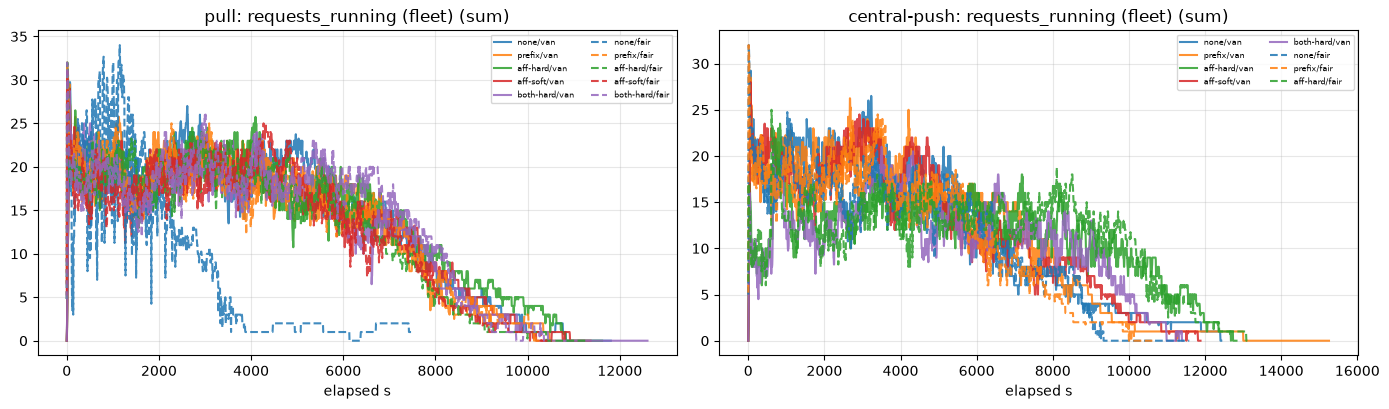

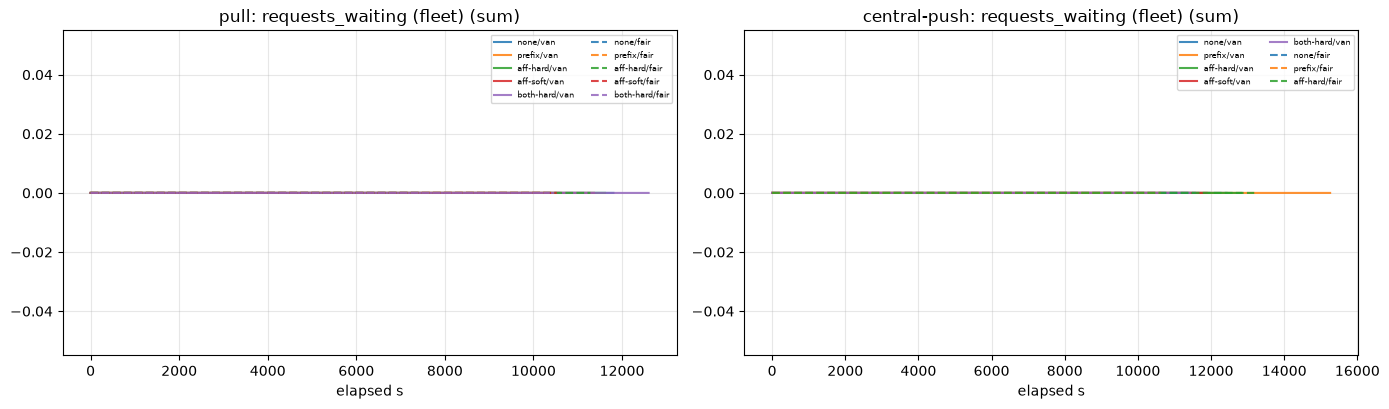

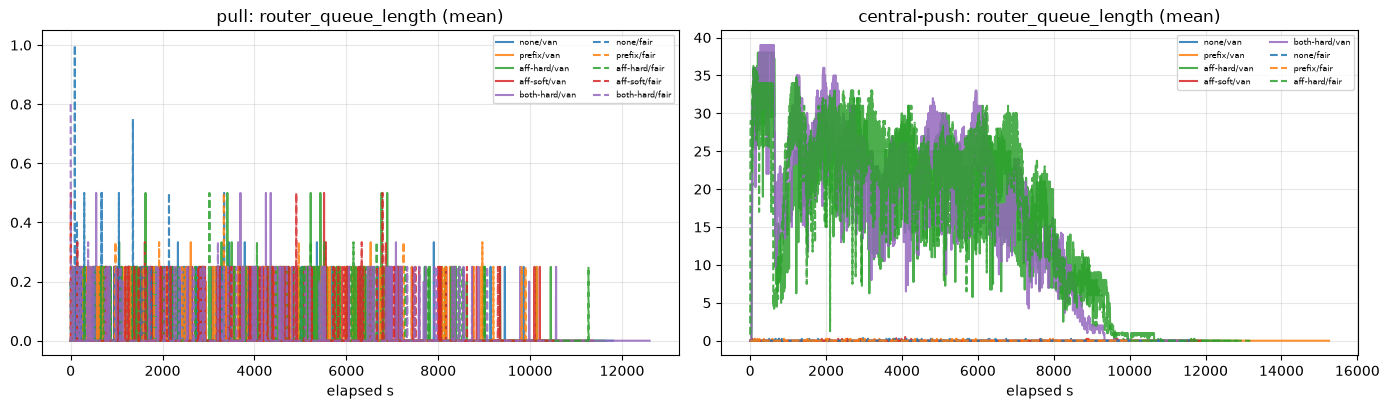

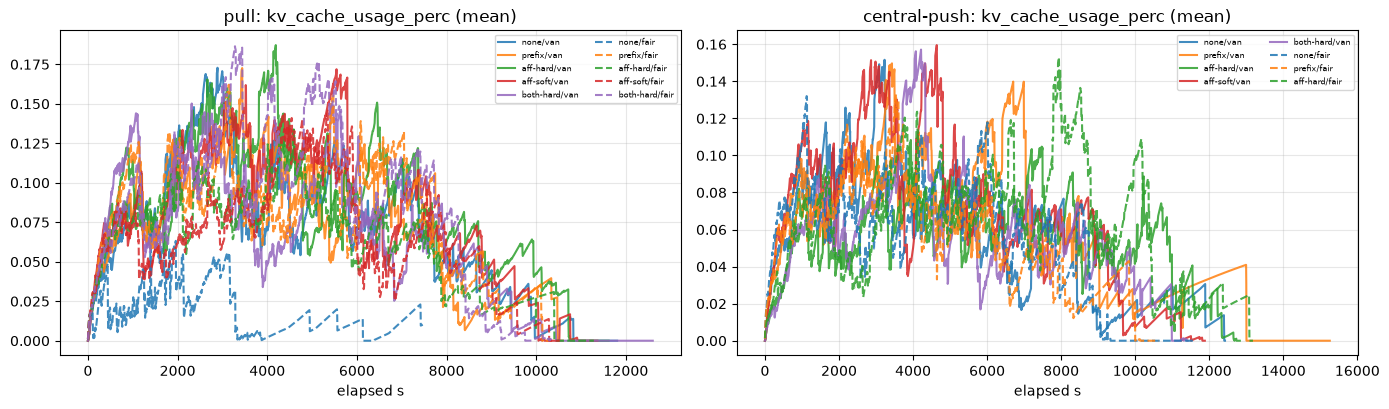

In [16]:
plot_fleet_by_mode("requests_running", "sum", "requests_running (fleet)")
plot_fleet_by_mode("requests_waiting", "sum", "requests_waiting (fleet)")
plot_fleet_by_mode("router_queue_length", "mean", "router_queue_length")
plot_fleet_by_mode("kv_cache_usage_perc", "mean", "kv_cache_usage_perc")

### 3b. Throughput + engine realized prefix-cache hit rate

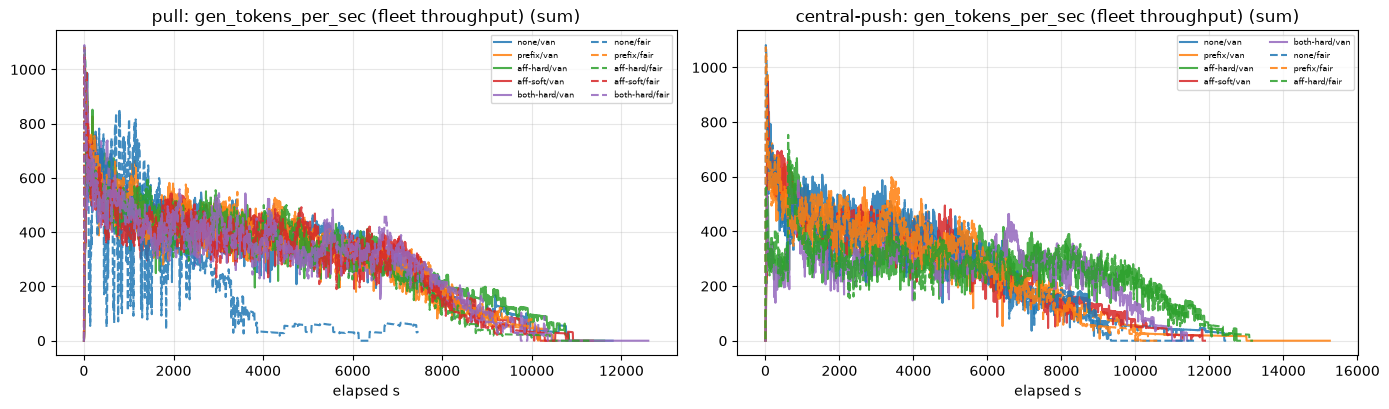

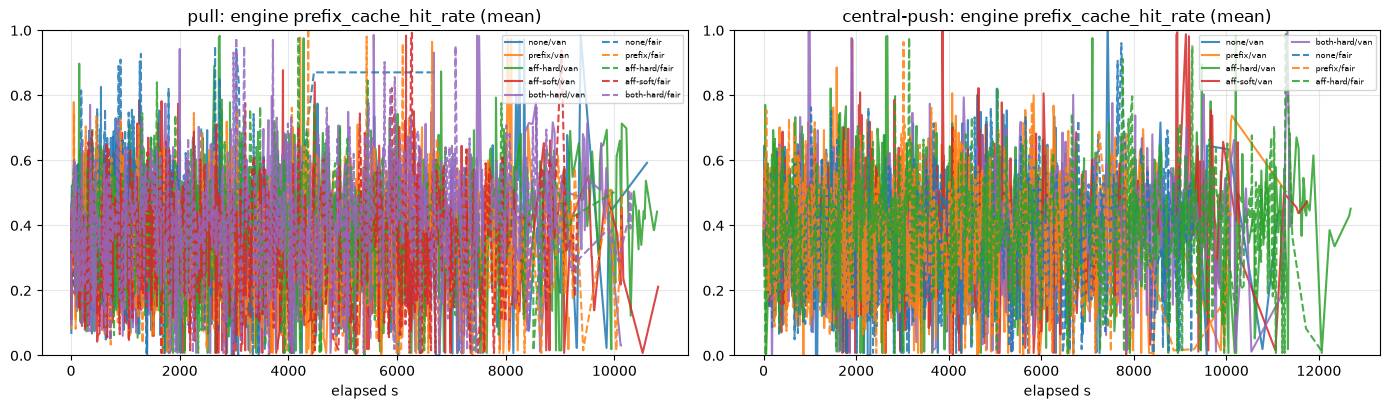

In [ ]:
plot_fleet_by_mode("gen_tokens_per_sec", "sum", "gen_tokens_per_sec (fleet throughput)")
plot_fleet_by_mode("prefix_cache_hit_rate", "mean", "engine prefix_cache_hit_rate", ylim=(0, 1))

## 4. Redis KV-block ownership + verification

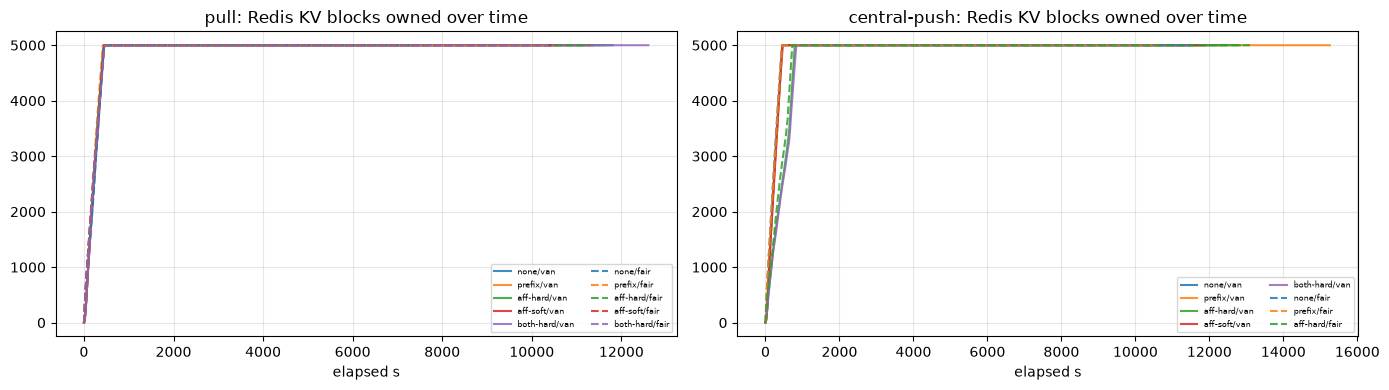

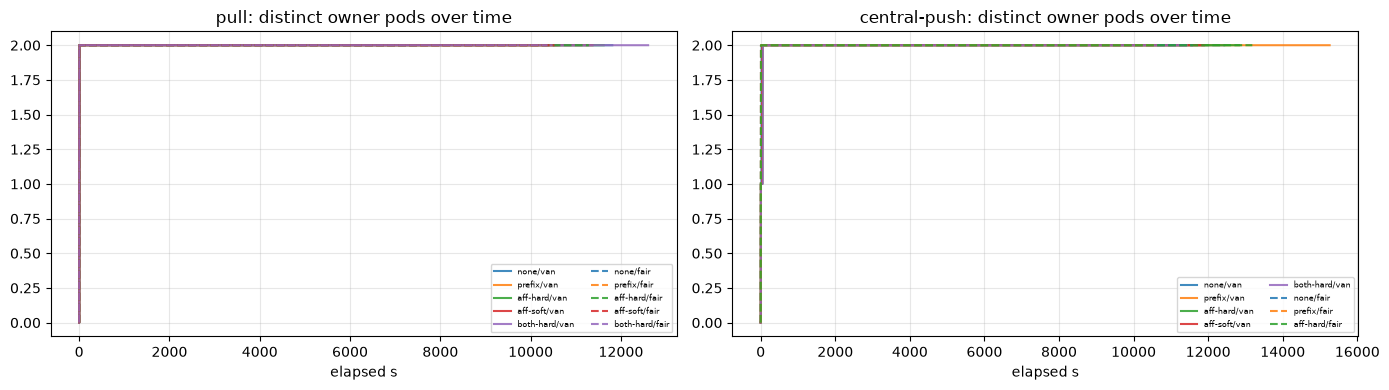

,checked,hashes_match,missing,records_with_hashes,peak_kv_blocks
label,,,,,
69:pull/none/van,None,None,None,None,5000
70:pull/prefix/van,None,None,None,None,5000
71:pull/aff-hard/van,None,None,None,None,5000
72:pull/aff-soft/van,None,None,None,None,5000
73:pull/both-hard/van,None,None,None,None,5000
74:pull/none/fair,None,None,None,None,5000
75:pull/prefix/fair,None,None,None,None,5000
76:pull/aff-hard/fair,None,None,None,None,5000
77:pull/aff-soft/fair,None,None,None,None,5000


In [ ]:
def load_kvwatch(exp_id):
    rows = _read_ndjson(exp_dir(exp_id) / "redis_kv_watch.jsonl")
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["exp"] = exp_id; df["label"] = LABELS[exp_id]
    if "ts" in df.columns:
        df["t_s"] = df["ts"] - df["ts"].min()
    kb = "kv_blocks" if "kv_blocks" in df.columns else ("keys" if "keys" in df.columns else None)
    df["kv_blocks_"] = df[kb] if kb else np.nan
    return df

KVW = {e: load_kvwatch(e) for e in EXP_IDS}

_modes = [m for m in ["pull", "central-push"] if (REG["router_mode"] == m).any()]
_scolors = {s: c for s, c in zip(STRAT_ORDER, plt.cm.tab10.colors)}
for metric, tt in [("kv_blocks_", "Redis KV blocks owned"),
                   ("unique_owners", "distinct owner pods")]:
    have = any((not KVW[e].empty) and (metric in KVW[e].columns) for e in EXP_IDS)
    if not have:
        continue
    fig, axes = plt.subplots(1, len(_modes), figsize=(7 * len(_modes), 4), squeeze=False)
    for ax, m in zip(axes.ravel(), _modes):
        for e in EXP_IDS:
            if REG.loc[e, "router_mode"] != m:
                continue
            d = KVW[e]
            if d.empty or "t_s" not in d.columns or metric not in d.columns:
                continue
            sl = str(REG.loc[e, "strat_lab"]); fair = bool(REG.loc[e, "fair"])
            ax.plot(d["t_s"], d[metric], color=_scolors.get(sl, "grey"),
                    ls="--" if fair else "-", alpha=.85,
                    label=f"{sl}/{'fair' if fair else 'van'}")
        ax.set_title(f"{m}: {tt} over time"); ax.set_xlabel("elapsed s"); ax.grid(alpha=.3)
        ax.legend(fontsize=6, ncol=2)
    plt.tight_layout(); plt.show()

ver = []
for e in EXP_IDS:
    v = _read_json(exp_dir(e) / "redis_verify.json") or {}
    ver.append({"label": LABELS[e], "checked": v.get("checked"),
                "hashes_match": v.get("hashes_match"), "missing": v.get("missing"),
                "records_with_hashes": v.get("records_with_hashes"),
                "peak_kv_blocks": (None if KVW[e].empty else (int(np.nanmax(KVW[e]["kv_blocks_"]))
                                   if KVW[e]["kv_blocks_"].notna().any() else None))})
display(pd.DataFrame(ver).set_index("label").reindex([LABELS[e] for e in EXP_IDS]))

## 5. Head-to-head summary

In [ ]:
summary = REG[["router_mode", "fair", "strat_lab", "batch"]].copy()
summary["label"] = [LABELS[e] for e in summary.index]
summary = summary.set_index("label")

def _get(df, label, col):
    try:
        return df.loc[label, col]
    except Exception:
        return np.nan

for e in EXP_IDS:
    lab = LABELS[e]
    # --- KV-affinity quality ---
    summary.loc[lab, "kv_hit_frac"] = _get(kv_tbl, lab, "kv_hit_frac")
    summary.loc[lab, "kv_hit_repeat"] = _get(kv_tbl, lab, "repeat") if "repeat" in kv_tbl.columns else np.nan
    summary.loc[lab, "sticky_frac"] = _get(STICK, lab, "sticky_frac")
    summary.loc[lab, "avg_distinct_ep"] = _get(STICK, lab, "avg_distinct_ep")
    # --- fairness / load balance ---
    summary.loc[lab, "req_jain"] = _get(FAIR, lab, "req_jain")
    summary.loc[lab, "req_cov"] = _get(FAIR, lab, "req_cov")
    summary.loc[lab, "inflight_cov"] = _get(FAIR, lab, "inflight_cov_mean")
    # --- latency / reliability ---
    summary.loc[lab, "e2e_p50"] = _get(LAT, lab, "e2e_p50")
    summary.loc[lab, "e2e_p95"] = _get(LAT, lab, "e2e_p95")
    summary.loc[lab, "e2e_p99"] = _get(LAT, lab, "e2e_p99")
    summary.loc[lab, "ttft_p50"] = _get(LAT, lab, "ttft_p50")
    summary.loc[lab, "near_timeout"] = _get(LAT, lab, "near_timeout")
    summary.loc[lab, "failed"] = _get(LAT, lab, "failed")
    # --- throughput (from metrics_summary.json if present) ---
    summary.loc[lab, "gen_tok_s"] = _get(MS, lab, "sum_generation_tokens_per_sec")

summary = summary.reindex([LABELS[e] for e in EXP_IDS])
print("Grid head-to-head (higher req_jain/kv_hit/sticky is better; lower cov/latency/timeout is better)")
display(summary.round(4))

Grid head-to-head (higher req_jain/kv_hit/sticky is better; lower cov/latency/timeout is better)


,router_mode,fair,strat_lab,batch,kv_hit_frac,kv_hit_repeat,sticky_frac,avg_distinct_ep,req_jain,req_cov,inflight_cov,e2e_p50,e2e_p95,e2e_p99,ttft_p50,near_timeout,failed,gen_tok_s
label,,,,,,,,,,,,,,,,,,
69:pull/none/van,pull,False,none,32,0.7435,0.7176,0.4230,1.5770,0.9999,0.0091,0.2324,98.6000,1495.8469,2002.4984,0.9256,0.0,0.0,292.8936
70:pull/prefix/van,pull,False,prefix,32,0.9979,1.0000,0.4828,1.5172,0.9939,0.0784,0.2762,100.3252,1459.5936,1948.0296,0.9200,0.0,0.0,310.6811
71:pull/aff-hard/van,pull,False,aff-hard,32,0.9986,1.0000,1.0000,1.0000,0.9971,0.0540,0.1836,102.3008,1620.0948,2198.1410,0.9289,0.0,0.0,300.2105
72:pull/aff-soft/van,pull,False,aff-soft,32,0.9979,1.0000,0.4275,1.5725,0.9975,0.0498,0.1919,97.1714,1499.8308,2024.2101,0.9193,0.0,0.0,294.2876
73:pull/both-hard/van,pull,False,both-hard,32,0.9986,1.0000,1.0000,1.0000,0.9994,0.0252,0.2556,101.9966,1610.9178,1996.2300,0.9403,0.0,0.0,260.1579
74:pull/none/fair,pull,True,none,32,0.9201,0.9334,0.3525,1.6475,0.9876,0.1122,0.6075,26.0154,452.6479,1389.8112,0.7917,0.0,0.0,211.9957
75:pull/prefix/fair,pull,True,prefix,32,0.9580,0.9710,0.4281,1.5719,0.9997,0.0161,0.1497,104.8533,1384.1395,1854.6521,0.9456,0.0,0.0,336.0243
76:pull/aff-hard/fair,pull,True,aff-hard,32,0.9944,1.0000,1.0000,1.0000,1.0000,0.0070,0.3240,99.7983,1483.3925,1965.4865,0.9640,0.0,0.0,285.0934
77:pull/aff-soft/fair,pull,True,aff-soft,32,0.9943,1.0000,0.3929,1.6071,0.9989,0.0333,0.2141,103.3939,1449.8899,2083.0610,0.9516,0.0,0.0,305.5530


### What to look for

**Fairness (load balance).** Fair pull should *raise* `req_jain` toward 1.0 and *lower* `req_cov` / `inflight_cov` vs the matching vanilla cell, and cut `e2e_p95`/`e2e_p99` and `near_timeout`. The effect should be largest where affinity concentrates load (aff-hard / both), and near-zero for `none` (already balanced, so fairness has little to fix).

**KV-affinity quality.** `affinity`/`both` (hard) should pin multi-turn conversations (`sticky_frac` ~ 1.0) and win on `kv_hit_frac` (especially `repeat` turns); `none`/`prefix` have no stickiness. `soft` is preference-only, so it can leak conversations across pods and lose repeat-turn hits.

**The tradeoff (section 2h).** Turning fairness ON can pull work off an overloaded, affinity-pinned pod, so watch whether `sticky_frac` / `kv_hit_frac` drop when `fair` is enabled. The ideal cell keeps affinity quality nearly unchanged while flattening load and improving tail latency.

**Mode.** `pull` vs `central-push` should give similar affinity/KV behavior; compare their load-balance and tail-latency response to fairness to see which dispatch path exploits the fairness throttle better.

---
## BZ tonight — fair high-load placeholders (96 users, prefix)

**After the runs**, register both exp ids below (and optionally into `REG`) and re-run the fairness / KV / latency summary cells for this A/B only.

| Series | Config | Fair | Users | exp_id | Status |
|---|---|---|---|---|---|
| 1 | `benchmark-bz-pull-prefix-highload` | OFF | 96 | **TBD** | pending |
| 2 | `benchmark-bz-pull-fair-prefix-highload` | ON | 96 | **TBD** | pending |

**Compare:** load balance (`req_jain`), waiting, TTFT/TPOT/e2e tails, timeout rate, KV-hit, stickiness.

**Log:** [`results-log/04-bz-fair-highload/000-…`](results-log/04-bz-fair-highload/000-fair-pull-a-b-at-96-users-prefix-tonight-placeholders.md) · legacy [`logs`](logs) Series 3–4.


In [ ]:
# Fill after tonight's sweeps (leave None until known).
BZ_FAIR_OFF = None     # Series 1 — prefix highload, fair OFF
BZ_FAIR_ON = None      # Series 2 — prefix highload, fair ON

print("BZ fair high-load placeholders:", {"fair_off": BZ_FAIR_OFF, "fair_on": BZ_FAIR_ON})
if BZ_FAIR_OFF is None or BZ_FAIR_ON is None:
    print("TODO: set exp ids, then compare with the same metrics used for exps 69–102.")
